In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load straight from the web — no download needed
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)

# ALWAYS look at your data first. These four lines are your reflex.
print(df.shape)          # (rows, columns) — how big is this?
df.head()                # first 5 rows — what does it look like?

(50411, 79)


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()                # column names, types, how many non-null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

In [6]:
# Filter rows where country equals Finland
finland = df[df["country"] == "Finland"]

# Keep only the columns we care about
cols = ["year", "co2", "co2_per_capita", "coal_co2", "oil_co2", "gas_co2"]
finland = finland[cols]

# Look at recent years
finland.tail(10)

,year,co2,co2_per_capita,coal_co2,oil_co2,gas_co2
17157,2015,44.192,8.065,16.843,21.384,4.726
17158,2016,47.252,8.598,18.660,22.939,4.208
17159,2017,44.657,8.107,17.088,22.213,3.887
17160,2018,45.736,8.292,17.924,22.044,4.415
17161,2019,42.444,7.687,15.257,21.648,4.314
17162,2020,37.720,6.821,11.853,20.261,4.382
17163,2021,37.820,6.825,12.711,19.468,4.356
17164,2022,36.337,6.525,12.579,20.124,2.410
17165,2023,31.799,5.677,9.391,18.806,2.575
17166,2024,29.775,5.301,7.784,18.189,2.779


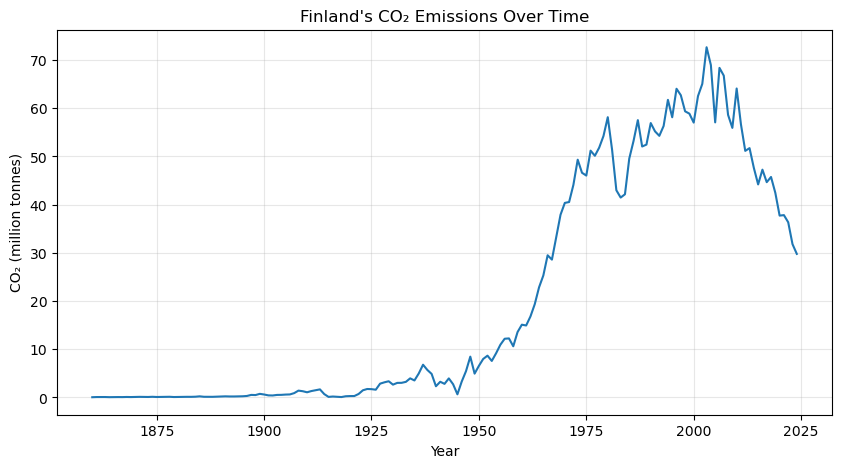

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(finland["year"], finland["co2"])
plt.title("Finland's CO₂ Emissions Over Time")
plt.xlabel("Year")
plt.ylabel("CO₂ (million tonnes)")
plt.grid(True, alpha=0.3)
plt.show()

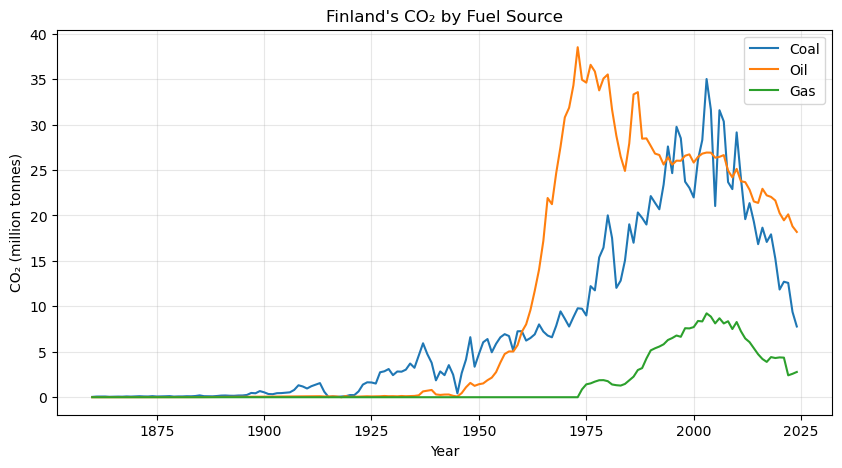

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(finland["year"], finland["coal_co2"], label="Coal")
plt.plot(finland["year"], finland["oil_co2"], label="Oil")
plt.plot(finland["year"], finland["gas_co2"], label="Gas")
plt.title("Finland's CO₂ by Fuel Source")
plt.xlabel("Year")
plt.ylabel("CO₂ (million tonnes)")
plt.legend()                    # shows which line is which
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
# Which countries emit the most per person in 2024?
recent = df[df["year"] == 2024]

# Drop aggregate rows like "World", "Europe" — keep real countries (they have an iso_code)
recent = recent[recent["iso_code"].notna()]

# Sort by per-capita emissions, take top 10
top10 = recent.sort_values("co2_per_capita", ascending=False).head(10)
top10[["country", "co2_per_capita", "co2"]]

,country,co2_per_capita,co2
37960,Qatar,41.271,125.812
24865,Kuwait,26.248,129.519
7662,Brunei,26.046,12.052
4514,Bahrain,24.270,39.003
45799,Trinidad and Tobago,22.932,34.576
40289,Saudi Arabia,20.379,692.133
47507,United Arab Emirates,20.131,221.988
32410,New Caledonia,18.064,5.287
41538,Sint Maarten (Dutch part),16.546,0.718
35885,Oman,15.651,82.662
